# DTEx231A. LodeSTAR to Detect Particles

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx231A_LodeSTAR_autotracker_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.

This example shows how to set up and train a LodeSTAR model to detect quantum dots.

In [2]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. Loading the Images of Quantum Dots

The data is found in the `tutorials/2-examples/assets` directory as an array with the format (time, height, width). This example contains 10 images.

In [3]:
images = np.load("./assets/image_quantum_dots.npy")
images.shape

(10, 256, 256, 1)

Normalize the array.

In [4]:
images = (images - np.min(images)) / np.ptp(images)

Plot a sample of the array.

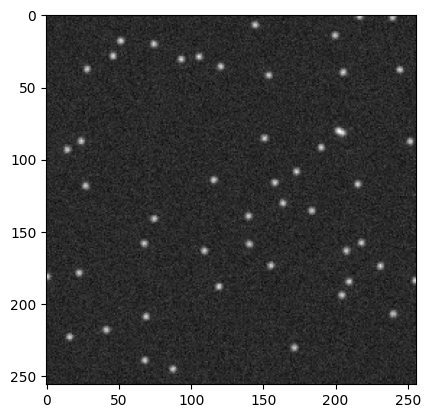

In [5]:
plt.imshow(images[0], cmap="gray")
plt.show()

## 2. Cropping One Quantum Dot

Select a crop of the training data.

In [6]:
crop = images[0, 100:132, 100:132]

Plot the crop.

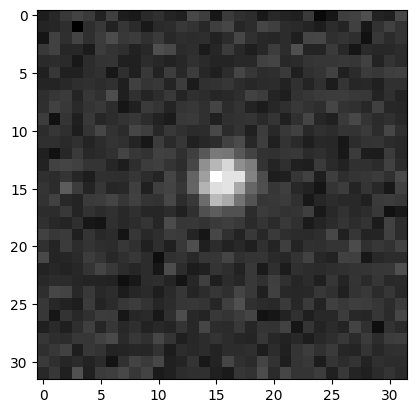

In [7]:
plt.imshow(crop, cmap="gray")

## 4. Training LodeSTAR
Initialize the training dataset and dataloader.

In [8]:
training_data = dt.Value(crop)

dataset = dt.pytorch.Dataset(
    training_data,
    length=128,
)

dataloader = dl.DataLoader(
    dataset=dataset,
    batch_size=4,
)

Initialize the LodeSTAR application containing both a CNN model and training logic.

In [9]:
lodestar = dl.LodeSTAR(
    n_transforms=4,
    optimizer=dl.Adam(lr=1e-3),
).build()

Initialize the trainer.

In [10]:
lodestar_trainer = dl.Trainer(accelerator="auto", max_epochs=50)

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Train the model.

In [11]:
lodestar_trainer.fit(lodestar, dataloader)

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
W0728 15:09:10.140000 17584 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:543: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accurate number, set `self.example_input_array` in your LightningModule.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvolutionalNeuralNetwork │  251 K │ train │     0 │
│ 1 │ between_loss  │ L1Loss                     │      0 │ train │     0 │
│ 2 │ within_loss   │ L1Loss                     │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection           │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection           │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection           │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam                       │      0 │ train │     0 │
└───┴───────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 251 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 251 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

## 5. Testing the Trained Model

Convert the images to Pytorch tensors for compatability. 

In [12]:
images_tensor = torch.from_numpy(images).to(torch.float32).moveaxis(-1, 1)

Choose inference parameters for particle detection and run detection.

In [13]:
alpha = 0.5
beta = 1 - alpha
cutoff = 0.9

all_detections = lodestar.detect(
    images_tensor, alpha=alpha, beta=beta, cutoff=cutoff, mode="quantile"
)

Overlay LodeSTAR predictions with the data to validate the model.

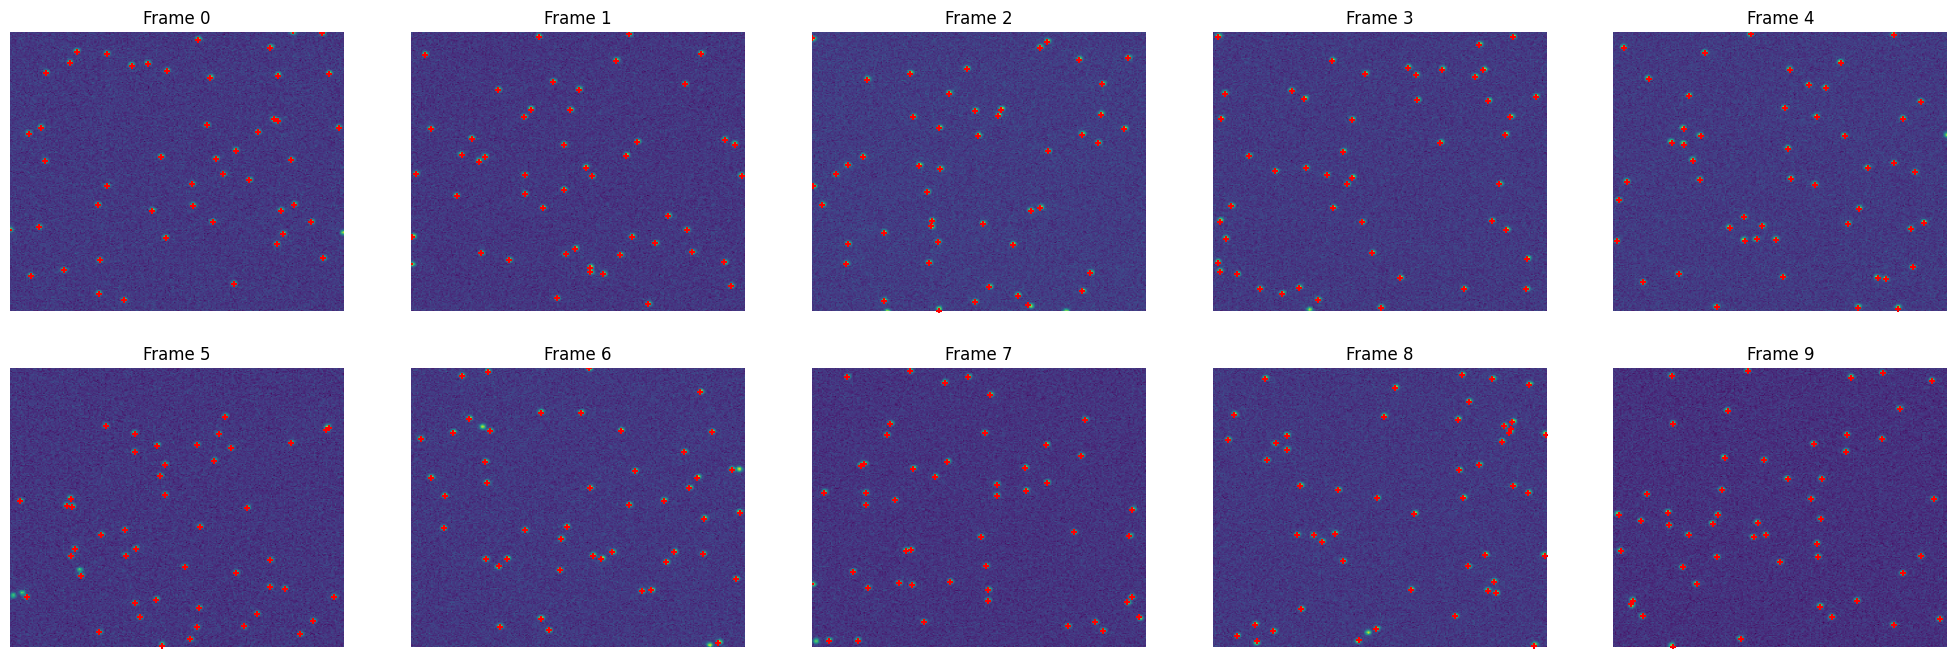

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(25, 8))

for i, (frame, detections) in enumerate(zip(images_tensor, all_detections)):

    ax = axes[i // 5, i % 5]
    img = frame.squeeze(0).detach().cpu()
    ax.imshow(img, aspect='auto')
    ax.scatter(
        detections[:, 1],
        detections[:, 0], marker="+", c="r" , s=20,
    )
    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(img.shape[0], 0) # inverted y, since image origin is top-left
    ax.axis("off")
    ax.set_title(f"Frame {i}")

plt.show()